# [Point-like Source Detection (`photutils.detection`)](https://photutils.readthedocs.io/en/latest/user_guide/detection.html)

One generally needs to identify astronomical sources in the data before performing photometry or other measurements. The [`photutils.detection`](https://photutils.readthedocs.io/en/latest/reference/detection_api.html#module-photutils.detection) subpackage provides tools to detect point-like (stellar) sources in an image. This subpackage also provides tools to find local peaks in an image that are above a specified threshold value.

For general-use source detection and extraction of both point-like and extended sources, please see [Image Segmentation](https://photutils.readthedocs.io/en/latest/user_guide/segmentation.html#image-segmentation).

## Detecting stars

Photutils includes two widely-used tools for detecting stars in an image, [DAOFIND](https://iraf.readthedocs.io/en/latest/tasks/noao/digiphot/apphot/daofind.html) and IRAF’s [starfind](https://iraf.readthedocs.io/en/latest/tasks/images/imcoords/starfind.html), plus a third tool that allows input of a custom user-defined kernel.

[`IRAFStarFinder`](https://photutils.readthedocs.io/en/latest/api/photutils.detection.IRAFStarFinder.html#photutils.detection.IRAFStarFinder) is a class that implements IRAF’s [starfind](https://iraf.readthedocs.io/en/latest/tasks/images/imcoords/starfind.html) algorithm. It is fundamentally similar to [`DAOStarFinder`](https://photutils.readthedocs.io/en/latest/api/photutils.detection.DAOStarFinder.html#photutils.detection.DAOStarFinder), but [`IRAFStarFinder`](https://photutils.readthedocs.io/en/latest/api/photutils.detection.IRAFStarFinder.html#photutils.detection.IRAFStarFinder) always uses a circular Gaussian kernel whereas [`DAOStarFinder`](https://photutils.readthedocs.io/en/latest/api/photutils.detection.DAOStarFinder.html#photutils.detection.DAOStarFinder) can use an elliptical Gaussian kernel. Another difference is that [`IRAFStarFinder`](https://photutils.readthedocs.io/en/latest/api/photutils.detection.IRAFStarFinder.html#photutils.detection.IRAFStarFinder) calculates the objects’ centroid, roundness, and sharpness using image moments.

The usage of [`IRAFStarFinder`](https://photutils.readthedocs.io/en/latest/api/photutils.detection.IRAFStarFinder.html#photutils.detection.IRAFStarFinder) and [`StarFinder`](https://photutils.readthedocs.io/en/latest/api/photutils.detection.StarFinder.html#photutils.detection.StarFinder) follows the same pattern as [`DAOStarFinder`](https://photutils.readthedocs.io/en/latest/api/photutils.detection.DAOStarFinder.html#photutils.detection.DAOStarFinder) shown below. Replace the class name and adjust the parameters (e.g., `fwhm and kernel`) as needed. Note that the `scale_threshold` parameter is specific to [`DAOStarFinder`](https://photutils.readthedocs.io/en/latest/api/photutils.detection.DAOStarFinder.html#photutils.detection.DAOStarFinder). Note also that each class returns different output columns. For example, [`DAOStarFinder`](https://photutils.readthedocs.io/en/latest/api/photutils.detection.DAOStarFinder.html#photutils.detection.DAOStarFinder) includes `daofind_mag` and `sharpness` columns, while [`IRAFStarFinder`](https://photutils.readthedocs.io/en/latest/api/photutils.detection.IRAFStarFinder.html#photutils.detection.IRAFStarFinder) includes `fwhm` and `pa` (position angle) columns. See each class’s API documentation for the full list of output columns.

As an example, let’s load a simulated HST star image and add Gaussian noise. We will then estimate the background and background noise using sigma-clipped statistics:

In [12]:
import numpy as np
from astropy.stats import sigma_clipped_stats
from photutils.datasets import load_simulated_hst_star_image, make_noise_image
from photutils.detection import DAOStarFinder
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
from photutils.aperture import CircularAperture, RectangularAperture
from photutils.detection import find_peaks

In [15]:
hdu = load_simulated_hst_star_image()
  # = retorna HDU (header/data unit), formato padrão astropy pra imagens astro 

data = hdu.data + make_noise_image(hdu.data.shape, distribution='gaussian',
                                  mean=10.0, stddev=5, seed=0)
# hdu.data -> extrai a matriz numérica que representa SÓ estreas
# make_noise_image() -> matriz de ruído do msm tamanho da imagem
    # usa distribuição gaussiana com:
    # mean=10.0 -> fundo do céu falso com valor médio de 10
    # stddev=5.0 -> ruído desse fundo varia com desvio padrão de 5
    # seed=0 -> garante que o mesmo padrão aleatório de ruído vai ser gerado
        # não importa quantas vezes rode

mean, median, std = sigma_clipped_stats(data, sigma=3.0)
# sigma_clipped_stats é melhor do que p np.mean(data) por:

# np.mean(data) -> o resultado seria um número mt alto pelas estrelas serem
    # muito brilhantes, a média iria distorcer a verdadeira média do céu

# sigma_clipped_stats -> calcula a média e o desvio padrão (sigma) de toda imagem
    # remove (corta) todos pixels acima de 3.0*sigma (remove estrelas brilhantes)
    # recalcula média e std só com os pixels que sobraram
    # itera até os números pararem de mudar

print(np.array((mean, median, std)))

[10.44410657 10.39699777  5.09141794]


Now we will subtract the background and use an instance of [`DAOStarFinder`](https://photutils.readthedocs.io/en/latest/api/photutils.detection.DAOStarFinder.html#photutils.detection.DAOStarFinder) to find the stars in the image that have FWHMs of around 2.5 pixels and have peaks approximately 5 times the background standard deviation above the background (i.e., the threshold is `5 * std`). The stars in the image are undersampled, so we will slightly relax the `sharpness_range` to allow for a wider range of values.

Running this class on the data yields an astropy [`QTable`](https://docs.astropy.org/en/stable/api/astropy.table.QTable.html#astropy.table.QTable) containing the results of the star finder:

In [16]:
threshold = 5.0 * std
# limiar de corte, definindo o brilho para algo ser considerado estrela
    # multiplicar por 5 -> só mostrar o objeto se ele for no mínimo 5x 
        # mais brilhante que o ruído de fundo do céu

daofind = DAOStarFinder(threshold, fwhm=2.5, sharpness_range=(0.2, 1.5))
# DAOStarFinder(filtros) -> os objetos só serão estrelas se passarem por esses fitros
# threshold -> calculado e explicado acima
# fwhm=2.5 -> Full Width at Half Maximum ouu Largura Total à Meia Altura
    # mede a largura de um pico em um gráfico na metade da sua altura máxima
    # 'largura' aproximada de 2.5 pixels medidos no ponto em que o brilho cai pela metade
    # pra caso o algoritmo encontre um pixel brilhante que forma um borrão de 20 pixels
    # de largura, ele não marca como estrela
# sharpness_range -> faixa de nitidez, filtro para o formato do objeto, 
    # o quão 'pontiagudo' ele é
    # uma estrela em forma de sino (gaussiana) tem uma nitidez em torno de 0.5
    # o intervalo (0.2, 1.5) quer filtrar só objetos cujo formato seja parecido com uma estrela
    # menor que 0.2 -> muito 'achatado', largo ou só achatado
    # maior que 1.5 -> muito 'fino', parecendo um risco

By default, [`DAOStarFinder`](https://photutils.readthedocs.io/en/latest/api/photutils.detection.DAOStarFinder.html#photutils.detection.DAOStarFinder) internally scales the input threshold by a factor derived from the convolution kernel to match the original [DAOFIND](https://iraf.readthedocs.io/en/latest/tasks/noao/digiphot/apphot/daofind.html) algorithm. To apply the threshold exactly as given (e.g., when supplying a spatial background-RMS map), set `scale_threshold=False`:

In [4]:
daofind_unscaled = DAOStarFinder(threshold, fwhm=2.5, 
                                sharpness_range=(0.2, 1.5),
                                scale_threshold=False)

Running the finder on the background-subtracted data:

In [17]:
# executar tudo que foi feito acima e fazer uma tabela de resultados

sources = daofind(data - median)
# sources -> retorna tabela astropy, vai ser usado abaixo
    # cada linha é uma estrela encontrada
    # cada coluna são as infromações delas
# daofind() -> executando o algoritmo anterior, aplicando os filtros
# data - median -> subtração do fundo do céu

for col in sources.colnames:
    if col not in ('id', 'n_pixels'):
        sources[col].info.format = '%.2f' 
# loop estético, arruma como os números vão aparecer na tela
# if col not in ('id', 'n_pixels') -> não vai formatar as colunas id
    # que é o nmr de identificação da estrela
    # n_pixels -> não vai formatar tbm
    # esse seria a quantidade de pixels que compõem a estrela, um nmr inteiro
# sources[col].info.format = '%.2f'  -> para todas as outras colunas ele força
    # a impressão de só 2 casas decimais

sources.pprint(max_lines=12, max_width=76)
    # .pprint() -> pretty print pra ter mais controle visual

 id x_centroid y_centroid sharpness ...   peak    flux   mag   daofind_mag
--- ---------- ---------- --------- ... ------- ------- ------ -----------
  1     848.57       2.15      0.89 ... 1051.78 3999.02  -9.00       -3.80
  2     181.85       3.75      0.97 ... 1711.87 5568.78  -9.36       -4.28
  3     323.88       3.70      0.96 ... 3005.97 9992.14 -10.00       -4.90
  4      99.89       8.95      1.07 ... 1134.12 3236.12  -8.78       -3.77
...        ...        ...       ... ...     ...     ...    ...         ...
497     114.16     993.47      0.84 ... 1577.91 6550.22  -9.54       -4.26
498     298.44     993.87      0.83 ...  644.97 2719.64  -8.59       -3.31
499     207.21     998.15      0.97 ... 2800.62 8406.16  -9.81       -4.83
500     691.03     998.77      1.15 ... 2600.83 5612.72  -9.37       -4.64
Length = 500 rows


Let’s plot the image and mark the location of detected sources:

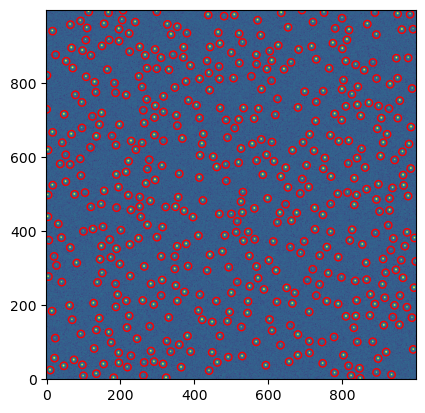

In [18]:
positions = np.transpose((sources['x_centroid'], sources['y_centroid']))
# preparar as coordenadas para o círculo
# a tabela acima tem as coordenadas em colunas separadas
    # x_centroid em uma e y_centroid em outra
# pra desenhar o círculo tem que ter uma lista de pares 
    # [(x1, y1), (x2, y2)...]
# np.transpose -> pega essas duas colunas e "gira" elas, juntando os valores em pares
# retorna um array onde cala linha representa uma estrela com 
    # suas coordenadas X e Y

apertures = CircularAperture(positions, r=10.0)
# criar os cículos ('aberturas')
# CircularAperture -> função photutils pra desenhar círculos
# positions -> coordenadas exatas do centro de cada estrela feito acima
# r=10.0 -> raio de cada círculo em pixels, 20 pixels de diametro

norm = simple_norm(data, 'sqrt', percent=99)
# ajustar o brilho da imagem pra enxergar bem
    # nas imagens astro, fundo do céu é muito escuro e as estrelas MUITO brilhantes
    # se for plotar isso diretamente, nao veremos o formato do círculo
# simple_norm -> normalização, ele estica os valores de brilho da imagem
# 'sqrt' -> raiz quadrada pra comprimir os valores muito altos (estrelas)
    # e expandir valores muito baixos (fundo do céu), ai da pra ver os dois 
# percent=99 ->  ignora os 1% mais brilhantes da imagem para a normalização 
    # se tiver um pixel estranho e muito brilhante, ele não vai estragar o contraste do resto

fig, ax = plt.subplots()
axim = ax.imshow(data, norm=norm, origin='lower')
# origin = 'lower' -> garante que as coordenadas X e Y calculadas acima batam exatamente 
    # com a imagem, pra imagem não ficar de cabeça pra baixo

patches = apertures.plot(ax=ax, color='red')

## Masking Regions

Regions of the input image can be masked by using the `mask` keyword with the [`DAOStarFinder`](https://photutils.readthedocs.io/en/latest/api/photutils.detection.DAOStarFinder.html#photutils.detection.DAOStarFinder), [`IRAFStarFinder`](https://photutils.readthedocs.io/en/latest/api/photutils.detection.IRAFStarFinder.html#photutils.detection.IRAFStarFinder), or [`StarFinder`](https://photutils.readthedocs.io/en/latest/api/photutils.detection.StarFinder.html#photutils.detection.StarFinder) instance. This simple example uses [`DAOStarFinder`](https://photutils.readthedocs.io/en/latest/api/photutils.detection.DAOStarFinder.html#photutils.detection.DAOStarFinder) and masks two rectangular regions. No sources will be detected in the masked regions:

In [9]:
daofind = DAOStarFinder(threshold, fwhm=2.5, sharpness_range=(0.2, 1.5))

mask = np.zeros(data.shape, dtype=bool)
mask[650:851, 600:851] = True
mask[250:451, 150:551] = True

sources = daofind(data - median, mask=mask)

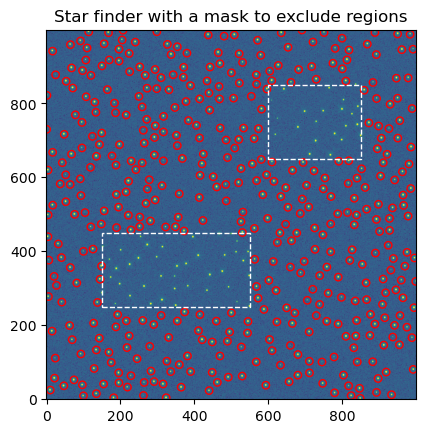

In [11]:
positions = np.transpose((sources['x_centroid'], sources['y_centroid']))
apertures = CircularAperture(positions, r=10.0)

fig, ax = plt.subplots()
norm = simple_norm(data, 'sqrt', percent=99)
axim = ax.imshow(data, norm=norm, origin='lower')
ax.set_title('Star finder with a mask to exclude regions')

p1 = apertures.plot(ax=ax, color='red')
rect1 = RectangularAperture((725, 750), 250, 200, theta=0)
rect2 = RectangularAperture((350, 350), 400, 200, theta=0)
p2 = rect1.plot(ax=ax, color='white', ls='dashed')
p3 = rect2.plot(ax=ax, color='white', ls='dashed')

# Local Peak Detection

Photutils also includes a [`find_peaks()`](https://photutils.readthedocs.io/en/latest/api/photutils.detection.find_peaks.html#photutils.detection.find_peaks) function to find local peaks in an image that are above a specified threshold value. Peaks are the local maxima above a specified threshold that are separated by a specified minimum number of pixels, defined by a box size or a local footprint.

In [14]:
threshold = median + (5.0 * std)
    # limiar de corte, mediana do fundo do ceu + 5 * desvio padrão
    # pra não detectar ruído como se fosse uma estrela

tbl = find_peaks(data, threshold, box_size=11)
    # find_peaks retorna uma tabela
tbl['peak_value'].info.format='%.8g'
    # uma das colunas da tabela se chama peak_value 
    # (brilho exato de cada pixel central de cada esterla encontrada)
    # pelos números serem muito grandes ou muito pequenos, foi definido
    # para ter ate 8 algarismos significativos

print(tbl)

 id x_peak y_peak peak_value
--- ------ ------ ----------
  1    849      2  1062.1752
  2    182      4  1722.2687
  3    324      4  3016.3684
  4    100      9  1144.5217
  5    824      9  1311.2049
  6    262     10  85.402256
  7    934     12  899.86707
  8    135     15  1488.0364
  9    780     17  948.56304
 10    893     18   603.0793
 11    440     23  1235.7136
 12     10     24  2656.7707
 13    847     29  2270.7851
...    ...    ...        ...
489    481    982  45.225948
490    437    985  1965.6847
491    508    985  2620.2846
492    984    987  741.57406
493    950    988  2693.0463
494    168    991  1695.6033
495    635    991  3621.9755
496    751    992  803.86612
497    889    992  194.27323
498    114    994  1588.3073
499    299    994  655.36699
500    207    998  2811.0195
501    691    999  2611.2233
Length = 501 rows


## API Reference

[Point-like Source Detection (photutils.detection)](https://photutils.readthedocs.io/en/latest/reference/detection_api.html)